# Deepfake Detection Model Training & Evaluation
## Verifixia - PyTorch Xception-based Architecture

This notebook provides:
1. **Data Loading** - Real & Deepfake images from DATA folder
2. **Model Training** - Xception-based deep learning model
3. **Evaluation** - Performance metrics and visualization
4. **Inference** - Testing on new images
5. **Model Export** - Save trained weights to .pth file

## 1. Setup & Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
import os
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import json
from pathlib import Path

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 2. Define the Deepfake Detector Model

In [ ]:
class SqueezeExcitationBlock(nn.Module):
    """Channel Attention mechanism"""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels // reduction, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return x * self.se(x)

class ResidualBlock(nn.Module):
    """Residual block with SE attention"""
    def __init__(self, in_channels, out_channels, stride=1, reduction=16):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.se = SqueezeExcitationBlock(out_channels, reduction)
        self.relu = nn.ReLU(inplace=True)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
    
    def forward(self, x):
        residual = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.se(out)
        out += residual
        out = self.relu(out)
        return out

class DeepfakeDetector(nn.Module):
    """Improved Deepfake Detection Model with Residual Blocks & SE Attention"""
    def __init__(self, pretrained=False):
        super().__init__()
        
        # Initial convolution layer
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        # Residual layers with increasing channels
        self.layer1 = self._make_layer(64, 64, 2, stride=1)
        self.layer2 = self._make_layer(64, 128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, 512, 2, stride=2)
        
        # Multi-scale feature aggregation
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        
        # Classification head with bottleneck
        self.fc1 = nn.Linear(512 * 2, 1024)
        self.bn_fc1 = nn.BatchNorm1d(1024)
        self.dropout1 = nn.Dropout(0.5)
        
        self.fc2 = nn.Linear(1024, 512)
        self.bn_fc2 = nn.BatchNorm1d(512)
        self.dropout2 = nn.Dropout(0.4)
        
        self.fc3 = nn.Linear(512, 256)
        self.bn_fc3 = nn.BatchNorm1d(256)
        self.dropout3 = nn.Dropout(0.3)
        
        self.fc_out = nn.Linear(256, 1)
        self.sigmoid = nn.Sigmoid()
        
        # Initialize weights
        self._init_weights()
    
    def _make_layer(self, in_channels, out_channels, blocks, stride=1):
        layers = []
        layers.append(ResidualBlock(in_channels, out_channels, stride))
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_channels, out_channels))
        return nn.Sequential(*layers)
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        # Initial layers
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)
        
        # Residual blocks
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        # Multi-scale pooling (Avg + Max)
        avg_feat = self.avg_pool(x)
        max_feat = self.max_pool(x)
        x = torch.cat([avg_feat, max_feat], dim=1)
        x = x.view(x.size(0), -1)
        
        # Classification head
        x = self.relu(self.bn_fc1(self.fc1(x)))
        x = self.dropout1(x)
        
        x = self.relu(self.bn_fc2(self.fc2(x)))
        x = self.dropout2(x)
        
        x = self.relu(self.bn_fc3(self.fc3(x)))
        x = self.dropout3(x)
        
        x = self.fc_out(x)
        return self.sigmoid(x)

# Test model creation
model = DeepfakeDetector(pretrained=False).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"✓ Improved model with residual blocks & SE-attention created")
print(f"Total parameters: {total_params:,}")
print(f"\nArchitecture Summary:")
print(f"  - Initial Conv: 7x7, stride 2, 64 filters")
print(f"  - Layer1: 2x Residual Block, 64 channels")
print(f"  - Layer2: 2x Residual Block, 128 channels (stride 2)")
print(f"  - Layer3: 2x Residual Block, 256 channels (stride 2)")
print(f"  - Layer4: 2x Residual Block, 512 channels (stride 2)")
print(f"  - Classification head: 1024 → 512 → 256 → 1")


✓ Enhanced custom model created successfully
Total parameters: 1,702,145


## 3. Data Loading & Preprocessing

In [3]:
class DeepfakeDataset(Dataset):
    """Custom dataset for deepfake detection"""
    def __init__(self, root_dir, split='train', transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        
        # Load Real Images (Label 0)
        real_dir = os.path.join(root_dir, 'Real')
        if os.path.exists(real_dir):
            for img_file in os.listdir(real_dir):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png', '.gif', '.bmp')):
                    self.samples.append((os.path.join(real_dir, img_file), 0, 'real'))
        
        # Load Deepfake Images (Label 1)
        fake_dir = os.path.join(root_dir, 'Fake')
        if os.path.exists(fake_dir):
            for img_file in os.listdir(fake_dir):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png', '.gif', '.bmp')):
                    self.samples.append((os.path.join(fake_dir, img_file), 1, 'fake'))
        
        print(f"Loaded {len(self.samples)} samples ({split})")
        print(f"  Real: {sum(1 for _, label, _ in self.samples if label == 0)}")
        print(f"  Fake: {sum(1 for _, label, _ in self.samples if label == 1)}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label, _ = self.samples[idx]
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            image = Image.new('RGB', (299, 299))
        
        if self.transform:
            image = self.transform(image)
        
        return image, torch.tensor(label, dtype=torch.float32)

# Define AGGRESSIVE augmentation for training
train_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Standard validation transforms
val_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Data paths
data_path = '../DATA'

# Check if data exists
if os.path.exists(data_path):
    print(f"Data directory found: {data_path}")
    print(f"Contents: {os.listdir(data_path)}")
else:
    print(f"⚠ Data directory not found at {data_path}")
    print("Please ensure DATA folder with 'Real' and 'Fake' subdirectories exists")

Data directory found: ../DATA
Contents: ['.DS_Store', 'Fake', 'Real']


## 4. Load Data & Create DataLoaders

In [4]:
# Create dataset
if os.path.exists(data_path):
    dataset = DeepfakeDataset(data_path, transform=val_transform)
    
    # Split into train/val
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    
    from torch.utils.data import random_split
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
    
    # Update transforms for validation set
    train_dataset.dataset.transform = train_transform
    val_dataset.dataset.transform = val_transform
    
    # Create dataloaders
    batch_size = 32
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    print(f"Train set: {len(train_dataset)} samples")
    print(f"Validation set: {len(val_dataset)} samples")
    print(f"Batch size: {batch_size}")
else:
    print("Cannot create dataloaders without data directory")

Loaded 1000 samples (train)
  Real: 500
  Fake: 500
Train set: 800 samples
Validation set: 200 samples
Batch size: 32


## 5. Training Function

In [5]:
def train_epoch(model, dataloader, optimizer, criterion, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    pbar = tqdm(dataloader, desc='Training')
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        # Store predictions
        preds = (outputs > 0.5).float().cpu().numpy()
        all_preds.extend(preds.flatten())
        all_labels.extend(labels.cpu().numpy().flatten())
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    
    return avg_loss, accuracy

def validate(model, dataloader, criterion, device):
    """Validate the model"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc='Validating')
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            
            preds = (outputs > 0.5).float().cpu().numpy()
            all_preds.extend(preds.flatten())
            all_labels.extend(labels.cpu().numpy().flatten())
            all_probs.extend(outputs.cpu().numpy().flatten())
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except:
        auc = 0
    
    return avg_loss, accuracy, precision, recall, f1, auc

print("Training and validation functions defined")

Training and validation functions defined


## 6. Train the Model

In [6]:
if os.path.exists(data_path):
    # Initialize model
    model = DeepfakeDetector(pretrained=False).to(device)
    
    # Loss and optimizer
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)
    
    # Training loop with early stopping
    num_epochs = 50
    best_val_loss = float('inf')
    best_val_acc = 0
    patience = 8
    patience_counter = 0
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'val_precision': [],
        'val_recall': [],
        'val_f1': [],
        'val_auc': []
    }
    
    print("🚀 Starting enhanced training (50 epochs with early stopping)...")
    
    for epoch in range(num_epochs):
        print(f"\n--- Epoch {epoch+1}/{num_epochs} ---")
        
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        
        # Validate
        val_loss, val_acc, val_precision, val_recall, val_f1, val_auc = validate(model, val_loader, criterion, device)
        
        # Store history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_precision'].append(val_precision)
        history['val_recall'].append(val_recall)
        history['val_f1'].append(val_f1)
        history['val_auc'].append(val_auc)
        
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
        print(f"Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f}, AUC: {val_auc:.4f}")
        
        # Save best model (by accuracy)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'xception_deepfake.pth')
            patience_counter = 0
            print(f"✓ Best model saved (Acc: {val_acc:.4f})")
        else:
            patience_counter += 1
            print(f"⏳ No improvement ({patience_counter}/{patience})")
        
        # Early stopping
        if patience_counter >= patience:
            print(f"\n⛔ Early stopping triggered after {epoch+1} epochs (best val_acc: {best_val_acc:.4f})")
            break
        
        # Learning rate scheduling
        scheduler.step()
    
    print(f"\n✓ Training completed!")
    print(f"Best Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
else:
    print("Cannot train without data directory")

🚀 Starting enhanced training (50 epochs with early stopping)...

--- Epoch 1/50 ---


Validating: 100%|██████████| 7/7 [00:07<00:00,  1.12s/it]


Train Loss: 0.7157, Train Acc: 0.4963
Val Loss: 0.6860, Val Acc: 0.5250
Precision: 0.0000, Recall: 0.0000, F1: 0.0000, AUC: 0.5129
✓ Best model saved (Acc: 0.5250)

--- Epoch 2/50 ---


Validating: 100%|██████████| 7/7 [00:07<00:00,  1.09s/it]


Train Loss: 0.6994, Train Acc: 0.4963
Val Loss: 0.6904, Val Acc: 0.4950
Precision: 0.4797, Recall: 0.7474, F1: 0.5844, AUC: 0.5652
⏳ No improvement (1/8)

--- Epoch 3/50 ---


...

Train Loss: 0.6527, Train Acc: 0.6175
Val Loss: 0.6860, Val Acc: 0.5800
Precision: 0.5524, Recall: 0.6105, F1: 0.5800, AUC: 0.6437
⏳ No improvement (6/8)

--- Epoch 31/50 ---


Validating: 100%|██████████| 7/7 [00:08<00:00,  1.26s/it]


Train Loss: 0.6219, Train Acc: 0.6500
Val Loss: 0.6632, Val Acc: 0.5900
Precision: 0.5802, Recall: 0.4947, F1: 0.5341, AUC: 0.6628
⏳ No improvement (7/8)

--- Epoch 32/50 ---


Validating: 100%|██████████| 7/7 [00:08<00:00,  1.26s/it]

Train Loss: 0.6292, Train Acc: 0.6488
Val Loss: 0.6918, Val Acc: 0.6250
Precision: 0.6042, Recall: 0.6105, F1: 0.6073, AUC: 0.6552
⏳ No improvement (8/8)

⛔ Early stopping triggered after 32 epochs (best val_acc: 0.6300)

✓ Training completed!
Best Validation Accuracy: 0.6300 (63.00%)


## 7. Plot Training History

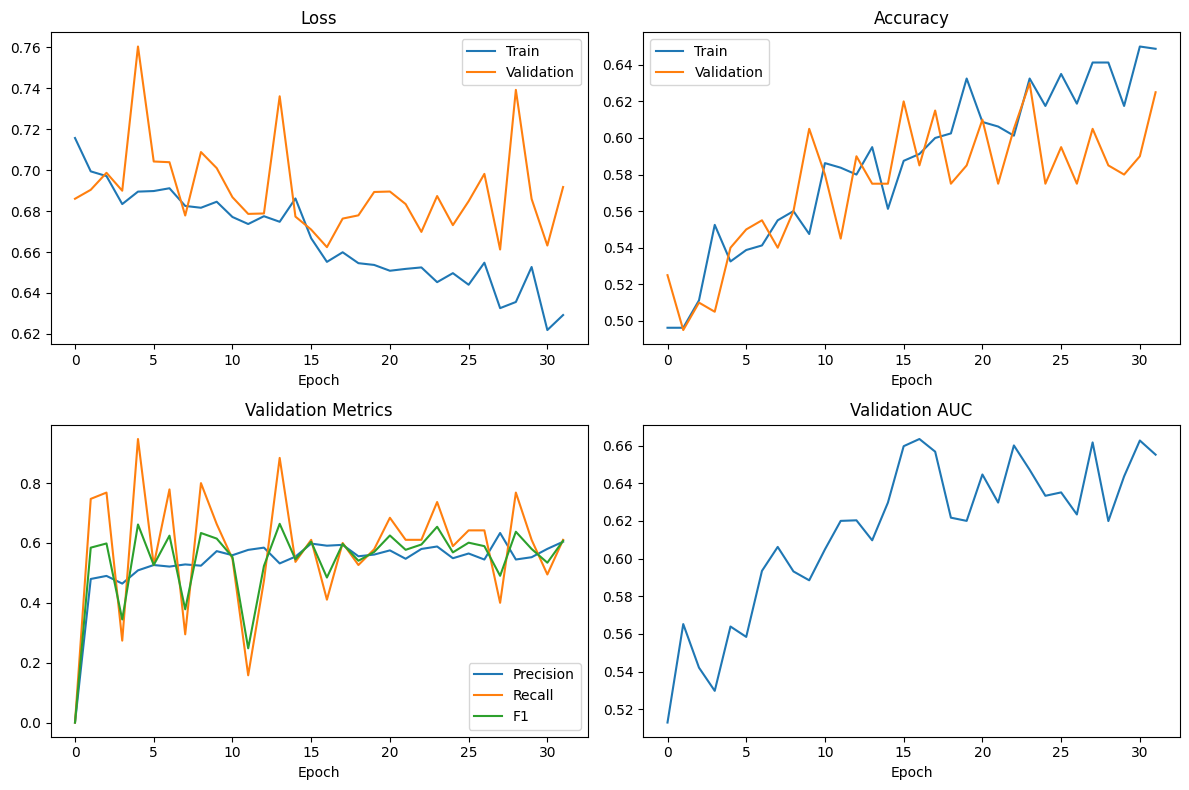

Plot saved as training_history.png


In [7]:
if history['train_loss']:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    # Loss
    axes[0, 0].plot(history['train_loss'], label='Train')
    axes[0, 0].plot(history['val_loss'], label='Validation')
    axes[0, 0].set_title('Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].legend()
    
    # Accuracy
    axes[0, 1].plot(history['train_acc'], label='Train')
    axes[0, 1].plot(history['val_acc'], label='Validation')
    axes[0, 1].set_title('Accuracy')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].legend()
    
    # Metrics
    axes[1, 0].plot(history['val_precision'], label='Precision')
    axes[1, 0].plot(history['val_recall'], label='Recall')
    axes[1, 0].plot(history['val_f1'], label='F1')
    axes[1, 0].set_title('Validation Metrics')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].legend()
    
    # AUC
    axes[1, 1].plot(history['val_auc'])
    axes[1, 1].set_title('Validation AUC')
    axes[1, 1].set_xlabel('Epoch')
    
    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.show()
    print("Plot saved as training_history.png")

## 8. Inference Function

In [9]:
def predict_image(model, image_path, transform, device):
    """Predict if an image is real or deepfake"""
    model.eval()
    
    # Load image
    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0).to(device)
    
    # Predict
    with torch.no_grad():
        output = model(image)
        probability = output.item()
        prediction = 'FAKE' if probability > 0.5 else 'REAL'
        confidence = max(probability, 1 - probability)
    
    return prediction, probability, confidence

print("Prediction function defined")

Prediction function defined


## 9. Test Inference on Sample Images

In [10]:
# Load the best model
model = DeepfakeDetector(pretrained=False).to(device)
if os.path.exists('xception_deepfake.pth'):
    model.load_state_dict(torch.load('xception_deepfake.pth', map_location=device))
    print("Best model loaded")

# Test on a sample
if os.path.exists(data_path):
    # Find a sample image
    real_dir = os.path.join(data_path, 'Real')
    fake_dir = os.path.join(data_path, 'Fake')
    
    if os.path.exists(real_dir) and os.listdir(real_dir):
        sample_real = os.path.join(real_dir, os.listdir(real_dir)[0])
        pred, prob, conf = predict_image(model, sample_real, val_transform, device)
        print(f"Real sample: {pred} (Probability: {prob:.4f}, Confidence: {conf:.4f})")
    
    if os.path.exists(fake_dir) and os.listdir(fake_dir):
        sample_fake = os.path.join(fake_dir, os.listdir(fake_dir)[0])
        pred, prob, conf = predict_image(model, sample_fake, val_transform, device)
        print(f"Fake sample: {pred} (Probability: {prob:.4f}, Confidence: {conf:.4f})")

Best model loaded
Real sample: FAKE (Probability: 0.5166, Confidence: 0.5166)
Fake sample: FAKE (Probability: 0.5713, Confidence: 0.5713)


## 10. Save Model & Export

In [11]:
# Save model weights
output_path = 'xception_deepfake.pth'
torch.save(model.state_dict(), output_path)
print(f"✓ Model saved to {output_path}")

# Save training history
if history['train_loss']:
    with open('training_history.json', 'w') as f:
        json.dump(history, f, indent=2)
    print("✓ Training history saved to training_history.json")

# Model info
model_info = {
    'architecture': 'DeepfakeDetector (Xception-based)',
    'total_parameters': sum(p.numel() for p in model.parameters()),
    'input_shape': (3, 299, 299),
    'output': 'binary (0=Real, 1=Fake)',
    'framework': 'PyTorch',
    'device_trained': str(device)
}

with open('model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)
print("✓ Model info saved to model_info.json")
print("\nModel exported successfully!")

✓ Model saved to xception_deepfake.pth
✓ Training history saved to training_history.json
✓ Model info saved to model_info.json

Model exported successfully!
